# 11 - Redesigned Stacking Ensemble: Forward-Chaining Folds

**Recap of the problem (notebook 05).** A stacking ensemble trains a *meta-learner* on the **out-of-fold predictions** of its expert models. The folds used to create those predictions matter:
* **random folds** leak (near-identical "twin" samples sit on both sides) but happened to work better;
* **leave-one-batch-out** folds avoid that, but include "hold out batch 1, train on batches 2-3": experts then predict the *past* from the *future*. The diagnostic showed very uneven out-of-fold quality
  (SVM only 53.7% accurate when batch 1 was held out) and the leakage-safe stacker ended up clearly worse than plain SVM.

> **The redesign: forward chaining.** Every out-of-fold prediction for batch *j* comes from experts trained **only on batches before j**:
> * fold 1: train on batch 1 -> predict batch 2; fold 2: train on batches 1-2 -> predict batch 3; ...
> * the meta-learner is trained on those predictions (batches 2, 3, ...), exactly the situation at deployment: *predict the next batch from the past*.
> * trade-off: the oldest batch has no out-of-fold predictions, so it cannot train the meta-learner (it still trains the experts).
> * with a single training batch (rolling split k = 2) forward chaining is impossible and all designs fall back to ordinary random folds.

**Declared before running anything**
* Experts: **SVM, kNN, Random Forest, Naive Bayes** (all defaults), meta-learner: default logistic regression. Gradient Boosting was dropped (about 100 s per fit and one of the weakest models); the old fold designs are
  **re-run with the same four experts**, so only the fold design differs.
* **Success criterion:** the forward stacker must beat the leave-one-batch-out stacker **and** be at least as good as the best single expert, under P1 (train B1-3) and under rolling retraining P3. Otherwise this is reported as a negative result.
* Pipelines: raw, PCA, LDA under P1; raw under P3. Significance: the two-level paired bootstrap and the verdict rule of notebook 10 (2,000 replicates), on a small pre-declared list of comparisons.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from src.data import load_all
from src.models import default_models
from src.stacking import BatchStackingClassifier, BASE_NAMES_FAST, make_fast_stackers
from src.stats import per_batch_f1, bootstrap_f1, two_level_means, percentile_ci, compare
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()
NEW = {"P1": pd.read_csv(RES / "11_predictions_P1.csv"), "P3": pd.read_csv(RES / "11_predictions_P3.csv")}
OLD = {"P1": pd.read_csv(RES / "10_predictions_P1.csv"), "P3": pd.read_csv(RES / "10_predictions_P3.csv")}   # single experts (notebook 10)
MASK = {"P1": batch >= 4, "P3": batch >= 2}; BATCHES = {"P1": list(range(4, 11)), "P3": list(range(2, 11))}
YT = {p: y[MASK[p]] for p in NEW}; BT = {p: batch[MASK[p]] for p in NEW}
EXPERTS = BASE_NAMES_FAST; STACKS = ["Stack4 (forward)", "Stack4 (batch CV)", "Stack4 (random CV)"]
def pred(proto, key): return (NEW[proto][key] if key in NEW[proto] else OLD[proto][key]).to_numpy()
def f1b(proto, key): return per_batch_f1(YT[proto], pred(proto, key), BT[proto], BATCHES[proto])
def accb(proto, key): p = pred(proto, key); return np.array([(p[BT[proto] == b] == YT[proto][BT[proto] == b]).mean() for b in BATCHES[proto]])
print({p: d.shape for p, d in NEW.items()})

{'P1': (10635, 9), 'P3': (13465, 3)}


## 0. Validation: the old fold designs, re-run here, must match the earlier diagnostic

Notebook 05 stored the per-batch macro-F1 of the batch-CV and random-CV stackers with exactly these four experts (P1, scaling only). The new run must reproduce them.

In [2]:
old = pd.read_csv(RES / "05_fast_subset_P1.csv", index_col=0)
for new_key, old_key in [("Stack4 (batch CV)", "stack (batch CV)"), ("Stack4 (random CV)", "stack (random CV)")]:
    mine = f1b("P1", f"P1|{new_key}|raw|default"); ref = old.loc[old_key, [str(b) for b in range(4, 11)]].astype(float).to_numpy()
    print(f"{new_key}: max difference to the notebook-05 diagnostic = {np.abs(mine - ref).max():.2e}")

Stack4 (batch CV): max difference to the notebook-05 diagnostic = 1.11e-16
Stack4 (random CV): max difference to the notebook-05 diagnostic = 2.22e-16


## 1. Why forward chaining should help: quality of the out-of-fold predictions

Accuracy of each expert on the batch it is asked to predict, when it is trained as the fold design prescribes (P1 training batches 1-3).
Forward chaining always predicts a *later* batch from *earlier* ones; leave-one-batch-out also asks for batch 1 from batches 2-3.

In [3]:
Z = StandardScaler().fit(X[batch <= 3]).transform(X[batch <= 3]); yt3, bt3 = y[batch <= 3], batch[batch <= 3]
dm = default_models(); rows = []
designs = {"forward chaining": [((1,), 2), ((1, 2), 3)], "leave-one-batch-out": [((2, 3), 1), ((1, 3), 2), ((1, 2), 3)]}
for design, folds in designs.items():
    for fit_b, val_b in folds:
        tr, va = np.isin(bt3, fit_b), bt3 == val_b
        r = {"design": design, "experts trained on": "+".join(map(str, fit_b)), "predict batch": val_b, "training samples": int(tr.sum()), "Toluene in training": int((yt3[tr] == 6).sum())}
        for n in EXPERTS: r[n] = accuracy_score(yt3[va], clone(dm[n]).fit(Z[tr], yt3[tr]).predict(Z[va]))
        rows.append(r)
oof = pd.DataFrame(rows); oof.to_csv(RES / "11_oof_quality.csv", index=False); display(oof.round(3))
fw, lo = oof[oof.design == "forward chaining"], oof[oof.design == "leave-one-batch-out"]
print(f"mean expert accuracy on the held-out batches: forward {fw[EXPERTS].to_numpy().mean():.3f} | leave-one-batch-out {lo[EXPERTS].to_numpy().mean():.3f}")

  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,design,experts trained on,predict batch,training samples,Toluene in training,SVM,kNN,Random Forest,Naive Bayes
0,forward chaining,1,2,445,74,0.534,0.547,0.755,0.659
1,forward chaining,1+2,3,1689,79,0.885,0.864,0.929,0.813
2,leave-one-batch-out,2+3,1,2830,5,0.537,0.847,0.593,0.456
3,leave-one-batch-out,1+3,2,2031,74,0.973,0.979,0.953,0.749
4,leave-one-batch-out,1+2,3,1689,79,0.885,0.864,0.929,0.813


mean expert accuracy on the held-out batches: forward 0.748 | leave-one-batch-out 0.798


**Whom does each meta-learner trust?** Share of the meta-learner's total weight given to each expert (fit on batches 1-3, scaling only), and how many rows (samples with out-of-fold predictions) the meta-learner is trained on.

,Stack4 (forward),Stack4 (batch CV),Stack4 (random CV)
SVM,21.0,18.7,21.0
kNN,24.0,29.8,26.3
Random Forest,30.0,30.1,41.3
Naive Bayes,25.0,21.4,11.4


rows used to train the meta-learner: {'Stack4 (forward)': 2830, 'Stack4 (batch CV)': 3275, 'Stack4 (random CV)': 3275}


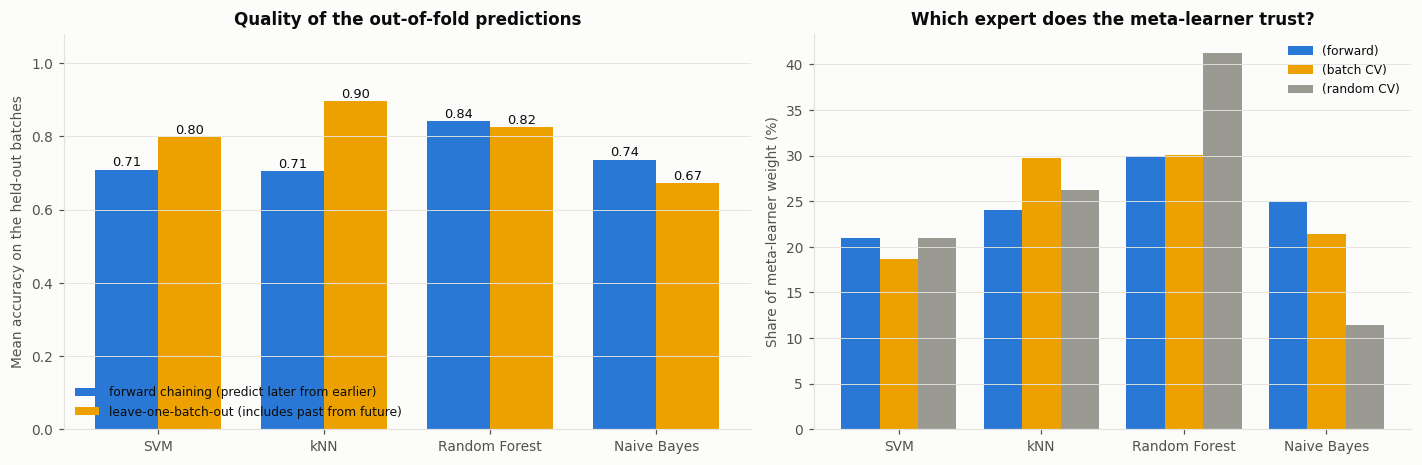

In [4]:
w, meta_rows = {}, {}
for name, st in make_fast_stackers().items():
    st = BatchStackingClassifier([(n, dm[n]) for n in EXPERTS], cv_strategy=st.cv_strategy, n_jobs=-1).fit(Z, yt3, groups=bt3)
    w[name] = st.base_weights(); meta_rows[name] = st.meta_rows_
W = pd.DataFrame(w).reindex(EXPERTS); W.to_csv(RES / "11_meta_weights.csv"); display((W * 100).round(1))
print("rows used to train the meta-learner:", meta_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]; xs = np.arange(len(EXPERTS)); bw = 0.38
ax.bar(xs - bw / 2, fw[EXPERTS].mean().values, bw, color=SERIES[0], label="forward chaining (predict later from earlier)")
ax.bar(xs + bw / 2, lo[EXPERTS].mean().values, bw, color=SERIES[3], label="leave-one-batch-out (includes past from future)")
for i, n in enumerate(EXPERTS):
    ax.text(i - bw / 2, fw[n].mean() + 0.01, f"{fw[n].mean():.2f}", ha="center", fontsize=8.5); ax.text(i + bw / 2, lo[n].mean() + 0.01, f"{lo[n].mean():.2f}", ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(EXPERTS); ax.set_ylim(0, 1.08); ax.set_ylabel("Mean accuracy on the held-out batches"); ax.grid(axis="x", visible=False)
ax.set_title("Quality of the out-of-fold predictions"); ax.legend(frameon=False, fontsize=8, loc="lower left")
ax = axes[1]; cols = {"Stack4 (forward)": SERIES[0], "Stack4 (batch CV)": SERIES[3], "Stack4 (random CV)": "#9a9992"}
for j, name in enumerate(STACKS): ax.bar(xs + (j - 1) * 0.27, W[name] * 100, 0.27, color=cols[name], label=name.replace("Stack4 ", ""))
ax.set_xticks(xs); ax.set_xticklabels(EXPERTS); ax.set_ylabel("Share of meta-learner weight (%)"); ax.grid(axis="x", visible=False)
ax.set_title("Which expert does the meta-learner trust?"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "40_stacker_oof_and_weights.png"); plt.show()

## 2. Results: P1 (train on batches 1-3, test on 4-10)

Mean over the 7 test batches. The four single experts use the same pipeline (notebook 10 predictions).

In [5]:
def summary(proto, keys):
    return pd.DataFrame([{"configuration": k.split("|")[1] + " | " + k.split("|")[2], "accuracy": accb(proto, k).mean(), "macro-F1": f1b(proto, k).mean()} for k in keys]).set_index("configuration")
rows = []
for v in ["raw", "PCA", "LDA"]:
    keys = [f"P1|{m}|{v}|default" for m in EXPERTS] + [f"P1|{s}|{v}|default" for s in STACKS]
    t = summary("P1", keys); t.insert(0, "pipeline", v); rows.append(t)
p1_table = pd.concat(rows); p1_table.to_csv(RES / "11_p1_summary.csv"); display(p1_table.round(3))

,pipeline,accuracy,macro-F1
configuration,,,
SVM | raw,raw,0.705,0.690
kNN | raw,raw,0.615,0.609
Random Forest | raw,raw,0.573,0.518
Naive Bayes | raw,raw,0.506,0.461
Stack4 (forward) | raw,raw,0.602,0.554
Stack4 (batch CV) | raw,raw,0.588,0.556
Stack4 (random CV) | raw,raw,0.694,0.649
SVM | PCA,PCA,0.666,0.660
kNN | PCA,PCA,0.601,0.594


## 3. Results: rolling retraining P3 (raw features)

For every test batch k the experts and the stacker are retrained on batches 1..k-1. For k = 2 there is one training batch, so all stackers use the same random-fold fallback.

,macro-F1 (B2-10),macro-F1 (B4-10),accuracy (B2-10)
configuration,,,
SVM,0.797,0.809,0.824
kNN,0.766,0.779,0.785
Random Forest,0.774,0.764,0.812
Naive Bayes,0.504,0.455,0.541
Stack4 (forward),0.688,0.708,0.736
Stack4 (batch CV),0.753,0.779,0.781
Stack4 (random CV),0.823,0.830,0.847


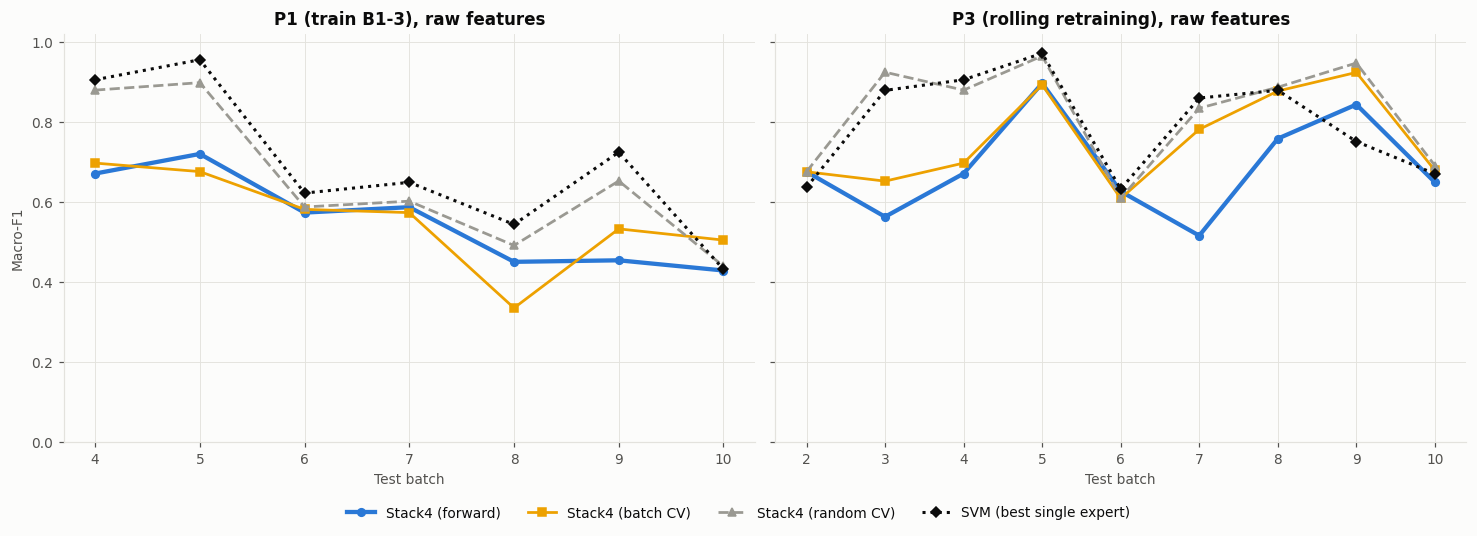

In [6]:
keys3 = [f"P3|{m}|raw|baseline" for m in EXPERTS] + [f"P3|{s}|raw|default" for s in STACKS]
t3 = pd.DataFrame([{"configuration": k.split("|")[1], "macro-F1 (B2-10)": f1b("P3", k).mean(), "macro-F1 (B4-10)": f1b("P3", k)[2:].mean(),
                    "accuracy (B2-10)": accb("P3", k).mean()} for k in keys3]).set_index("configuration")
t3.to_csv(RES / "11_p3_summary.csv"); display(t3.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
sty = {"Stack4 (forward)": (SERIES[0], "-", "o", 2.8), "Stack4 (batch CV)": (SERIES[3], "-", "s", 1.8), "Stack4 (random CV)": ("#9a9992", "--", "^", 1.8), "SVM": (INK, ":", "D", 2.0)}
for ax, proto, title in zip(axes, ["P1", "P3"], ["P1 (train B1-3), raw features", "P3 (rolling retraining), raw features"]):
    for name, (c, ls, m, lw) in sty.items():
        key = f"{proto}|{name}|raw|default" if name.startswith("Stack4") else (f"P1|SVM|raw|default" if proto == "P1" else "P3|SVM|raw|baseline")
        ax.plot(BATCHES[proto], f1b(proto, key), color=c, ls=ls, marker=m, ms=5, lw=lw, label=name if name != "SVM" else "SVM (best single expert)")
    ax.set_title(title); ax.set_xlabel("Test batch"); ax.set_xticks(BATCHES[proto]); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Macro-F1"); h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(); fig.savefig(FIG / "41_stacker_per_batch.png"); plt.show()

## 4. Pre-declared comparisons with confidence intervals

Difference in mean macro-F1 (A minus B), paired two-level bootstrap (2,000 replicates), verdict rule as in notebook 10. The "best single expert" in each pipeline is the one with the highest
mean macro-F1 on the same protocol, a comparator chosen on the test batches, i.e. *favourable to the experts and conservative for the stacker*.

,comparison,diff,ci2_lo,ci2_hi,A>B,p,verdict
0,P1 raw: forward vs batch CV,-0.002,-0.049,0.051,3/7,0.938,inconclusive
1,P1 raw: forward vs random CV,-0.095,-0.165,-0.036,0/7,0.016,clear
2,P1 raw: forward vs best expert (SVM),-0.135,-0.215,-0.063,0/7,0.016,clear
3,P1 PCA: forward vs batch CV,0.029,-0.026,0.094,4/7,0.375,suggestive
4,P1 PCA: forward vs random CV,-0.046,-0.086,-0.005,2/7,0.109,clear
5,P1 PCA: forward vs best expert (SVM),-0.045,-0.125,0.030,4/7,0.688,suggestive
6,P1 LDA: forward vs batch CV,-0.152,-0.218,-0.055,1/7,0.031,clear
7,P1 LDA: forward vs random CV,-0.168,-0.218,-0.101,0/7,0.016,clear
8,P1 LDA: forward vs best expert (Random Forest),-0.179,-0.262,-0.069,1/7,0.031,clear
9,P3 raw: forward vs batch CV,-0.065,-0.127,-0.016,2/9,0.039,clear


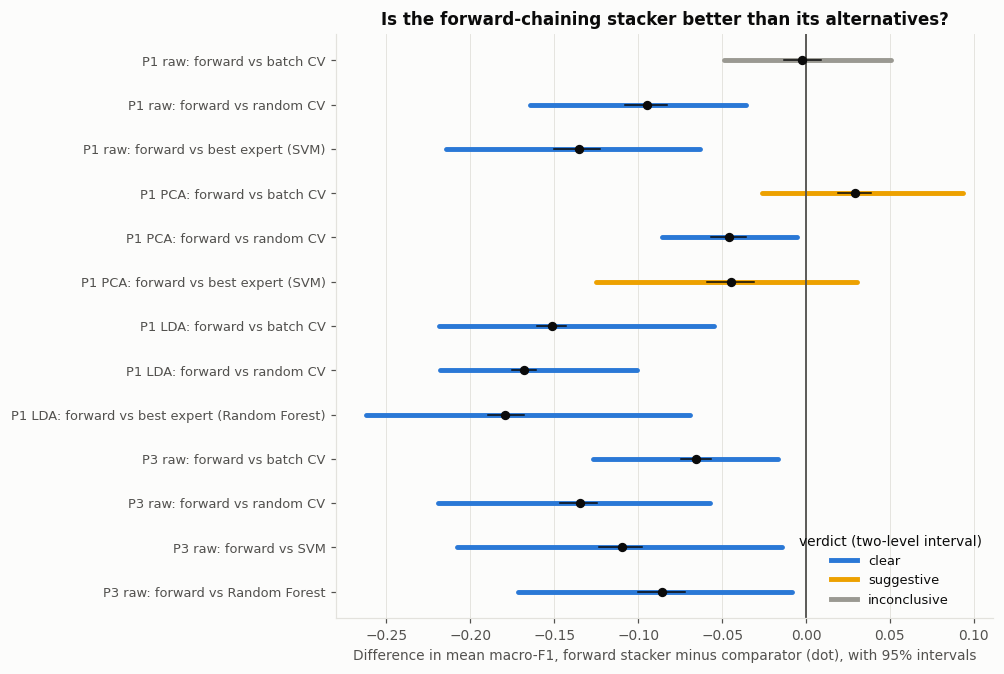

In [7]:
def best_expert(proto, v):
    keys = [f"P1|{m}|{v}|default" for m in EXPERTS] if proto == "P1" else [f"P3|{m}|raw|baseline" for m in EXPERTS]
    return max(keys, key=lambda k: f1b(proto, k).mean())
fam = []
for v in ["raw", "PCA", "LDA"]:
    f = f"P1|Stack4 (forward)|{v}|default"
    fam += [("P1", f, f"P1|Stack4 (batch CV)|{v}|default", f"P1 {v}: forward vs batch CV"), ("P1", f, f"P1|Stack4 (random CV)|{v}|default", f"P1 {v}: forward vs random CV"),
            ("P1", f, best_expert("P1", v), f"P1 {v}: forward vs best expert ({best_expert('P1', v).split('|')[1]})")]
f = "P3|Stack4 (forward)|raw|default"
fam += [("P3", f, "P3|Stack4 (batch CV)|raw|default", "P3 raw: forward vs batch CV"), ("P3", f, "P3|Stack4 (random CV)|raw|default", "P3 raw: forward vs random CV"),
        ("P3", f, "P3|SVM|raw|baseline", "P3 raw: forward vs SVM"), ("P3", f, "P3|Random Forest|raw|baseline", "P3 raw: forward vs Random Forest")]
res = []
for proto in ["P1", "P3"]:
    sub = [x for x in fam if x[0] == proto]; keys = sorted({k for x in sub for k in (x[1], x[2])})
    F, names = bootstrap_f1(YT[proto], {k: pred(proto, k) for k in keys}, BT[proto], BATCHES[proto], n_boot=2000, seed=42)
    point = {k: f1b(proto, k) for k in keys}
    for _, a, b, label in sub:
        c = compare(F, names, a, b, point)
        res.append({"comparison": label, "diff": c["diff"], "ci2_lo": c["ci_two_level"][0], "ci2_hi": c["ci_two_level"][1], "ci1_lo": c["ci_conditional"][0], "ci1_hi": c["ci_conditional"][1],
                    "A>B": f"{c['batches_A_better']}/{c['n_batches']}", "p": c["wilcoxon_p"], "verdict": c["verdict"]})
cmp_ = pd.DataFrame(res); cmp_.to_csv(RES / "11_comparisons.csv", index=False)
pd.set_option("display.width", 250); display(cmp_[["comparison", "diff", "ci2_lo", "ci2_hi", "A>B", "p", "verdict"]].round(3))

col = {"clear": SERIES[0], "suggestive": SERIES[3], "inconclusive": "#9a9992"}; d = cmp_.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9.2, 6.2))
for i, r in d.iterrows():
    ax.plot([r.ci2_lo, r.ci2_hi], [i, i], color=col[r.verdict], lw=3.2, solid_capstyle="round", zorder=2); ax.plot([r.ci1_lo, r.ci1_hi], [i, i], color=INK, lw=1.0, zorder=3); ax.scatter(r["diff"], i, color=INK, s=26, zorder=4)
ax.axvline(0, color=INK2, lw=1.2); ax.set_yticks(range(len(d))); ax.set_yticklabels(d.comparison, fontsize=8.5); ax.grid(axis="y", visible=False)
ax.set_xlabel("Difference in mean macro-F1, forward stacker minus comparator (dot), with 95% intervals"); ax.set_title("Is the forward-chaining stacker better than its alternatives?")
for v in ["clear", "suggestive", "inconclusive"]: ax.plot([], [], color=col[v], lw=3.2, label=v)
ax.legend(frameon=False, fontsize=8.5, loc="lower right", title="verdict (two-level interval)"); fig.tight_layout(); fig.savefig(FIG / "42_stacker_comparisons.png"); plt.show()

## 5. Exploratory (post hoc, NOT pre-declared): how does the random-fold stacker compare with the experts?

The random-fold stacker scored highest under rolling retraining, which was not anticipated, so the comparisons below were added **after** seeing that result. Treat them as hypotheses for future work,
not as findings: they were not in the declared list, so no multiple-comparison protection applies.

In [8]:
expl = []
for proto, pairs in {"P3": [("P3|Stack4 (random CV)|raw|default", "P3|SVM|raw|baseline", "P3 raw: random-CV stack vs SVM"), ("P3|Stack4 (random CV)|raw|default", "P3|Random Forest|raw|baseline", "P3 raw: random-CV stack vs Random Forest"),
                                 ("P3|Stack4 (random CV)|raw|default", "P3|kNN|raw|baseline", "P3 raw: random-CV stack vs kNN")],
                     "P1": [("P1|Stack4 (random CV)|raw|default", "P1|SVM|raw|default", "P1 raw: random-CV stack vs SVM"), ("P1|Stack4 (random CV)|PCA|default", "P1|SVM|PCA|default", "P1 PCA: random-CV stack vs SVM")]}.items():
    keys = sorted({k for a, b, _ in pairs for k in (a, b)})
    F, names = bootstrap_f1(YT[proto], {k: pred(proto, k) for k in keys}, BT[proto], BATCHES[proto], n_boot=2000, seed=42); point = {k: f1b(proto, k) for k in keys}
    for a, b, label in pairs:
        c = compare(F, names, a, b, point)
        expl.append({"comparison (exploratory)": label, "diff": c["diff"], "two-level 95% CI": f"[{c['ci_two_level'][0]:+.3f}, {c['ci_two_level'][1]:+.3f}]", "A>B": f"{c['batches_A_better']}/{c['n_batches']}", "verdict": c["verdict"]})
expl = pd.DataFrame(expl); expl.to_csv(RES / "11_exploratory_comparisons.csv", index=False); display(expl.round(3))

,comparison (exploratory),diff,two-level 95% CI,A>B,verdict
0,P3 raw: random-CV stack vs SVM,0.025,"[-0.013, +0.074]",5/9,suggestive
1,P3 raw: random-CV stack vs Random Forest,0.049,"[+0.005, +0.098]",6/9,clear
2,P3 raw: random-CV stack vs kNN,0.056,"[+0.025, +0.097]",8/9,clear
3,P1 raw: random-CV stack vs SVM,-0.040,"[-0.063, -0.016]",1/7,clear
4,P1 PCA: random-CV stack vs SVM,0.001,"[-0.080, +0.068]",5/7,inconclusive


## 6. Key takeaways

Experts: SVM, kNN, Random Forest, Naive Bayes (defaults); meta-learner: default logistic regression. The old fold designs were re-run with the same four experts and reproduce the notebook-05 diagnostic to 1e-16. Numbers are mean macro-F1 (accuracy) over the test batches.

| | P1 raw | P1 PCA | P1 LDA | P3 raw (B2-10) |
|---|---|---|---|---|
| **Forward chaining (redesign)** | 0.554 (0.602) | 0.615 (0.677) | 0.445 (0.581) | 0.688 (0.736) |
| Leave-one-batch-out | 0.556 (0.588) | 0.586 (0.593) | 0.597 (0.624) | 0.753 (0.781) |
| Random folds | 0.649 (0.694) | 0.661 (0.702) | 0.614 (0.656) | 0.823 (0.847) |
| Best single expert | SVM 0.690 (0.705) | SVM 0.660 (0.666) | Random Forest 0.625 (0.647) | SVM 0.797 (0.824) |

1. **The redesign did not work; the pre-declared success criterion is not met.** The forward-chaining stacker is not better than leave-one-batch-out (P1 raw: -0.002, inconclusive; P1 LDA: -0.152, clearly worse; P3: -0.065, clearly worse, [-0.127, -0.016]), and it is clearly worse than the best single expert (P1 raw: -0.135 vs SVM, [-0.215, -0.063], worse on all 7 batches; P3: -0.109 vs SVM, [-0.208, -0.014]). The only favourable difference is P1 with PCA (+0.029 vs leave-one-batch-out, suggestive: [-0.026, +0.094], better on 4 of 7 batches). Of 13 declared comparisons, 10 are clear (all against the redesign), 2 suggestive and 1 inconclusive.
2. **Why: the forward folds produce unrepresentatively weak out-of-fold predictions.** The first forward fold trains the experts on batch 1 alone (445 samples) and predicts batch 2: SVM reaches only 53.4% accuracy and kNN 54.7% (Random Forest 75.5%, Naive Bayes 65.9%), compared with 88.5% / 86.4% / 92.9% / 81.3% in the second fold, and the final experts are trained on far more data than either fold. The meta-learner is therefore fitted to experts that are weaker, and ranked differently, than the ones it will actually combine. The LDA collapse (0.445) fits this: LDA fitted on 445 samples is already known to fail (notebook 03). The loss is concentrated on a few batches in P3: test batch 3 (forward 0.562 vs 0.923 for random folds) and test batch 7 (0.515 vs 0.833). These are explanations supported by the numbers above, not proven mechanisms.
3. **The same lesson as for tuning: near-term validation does not predict far-future performance.** The meta-learner learns its expert weights from near-term out-of-fold behaviour, where the experts look similar, and so spreads weight almost evenly (forward: SVM 21.0%, kNN 24.0%, Random Forest 30.0%, Naive Bayes 25.0%), although on the test batches SVM is by far the strongest expert and Naive Bayes the weakest. It never discovers the ranking that matters later.
4. **The mean accuracy of the out-of-fold predictions is not the point.** It is actually lower for forward chaining (0.748) than for leave-one-batch-out (0.798), because the latter includes easy folds where an expert trained on two batches predicts a batch in between (SVM 97.3%). Representativeness of the fold, not its accuracy, was the design goal, and it did not translate into better stacking here.
5. **Exploratory only (not pre-declared): random folds look best under rolling retraining, but not clearly better than SVM.** The random-fold stacker reaches 0.823 vs SVM 0.797 on P3 (+0.025, two-level interval [-0.013, +0.074], better on 5 of 9 batches: suggestive), is clearly better than Random Forest (+0.049) and kNN (+0.056) there, but is clearly *worse* than SVM on P1 with raw features (-0.040, [-0.063, -0.016]) and equal with PCA. This was a post hoc comparison and should be treated as a hypothesis.
6. **Overall conclusion on stacking.** Across notebooks 05 and 11 (four fold designs, three pipelines, two protocols) no leakage-safe stacker beat the best single model, and no stacker beat it clearly on both protocols. In this benchmark an ensemble is not a route to drift robustness: the experts' mistakes under drift are largely shared, so there is little for a meta-learner to exploit, and any weights learned from near-term data do not transfer to distant batches.
7. **Caveats.** Four experts, default settings and a default meta-learner; rolling splits k = 2 and 3 have only one or two training batches, so forward chaining has one fold or none; the P1 numbers inherit the Toluene problem (the experts never recognise it later); the exploratory comparison was not pre-declared.